# 📌 Extracción

In [32]:
import pandas as pd
import requests
import json

In [33]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

In [36]:
try:
    response = requests.get(url)
    data = response.json()
    
    df = pd.DataFrame(data)
    
    print("Extracción exitosa")
except Exception as e:
    print(f"Error en la extracción: {e}")

Extracción exitosa


In [37]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔧 Transformación

In [38]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

In [39]:
df_final = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

In [40]:
columnas = {
    'customerID': 'ID_Cliente', 'Churn': 'Evasion', 'gender': 'Genero', 
    'SeniorCitizen': 'Adulto_Mayor', 'Partner': 'Socio', 'Dependents': 'Dependientes',
    'tenure': 'Meses_Permanencia', 'PhoneService': 'Servicio_Telefono', 
    'MultipleLines': 'Lineas_Multiples', 'InternetService': 'Servicio_Internet', 
    'OnlineSecurity': 'Seguridad_Online', 'OnlineBackup': 'Respaldo_Online', 
    'DeviceProtection': 'Proteccion_Dispositivo', 'TechSupport': 'Soporte_Tecnico', 
    'StreamingTV': 'Streaming_TV', 'StreamingMovies': 'Streaming_Peliculas', 
    'Contract': 'Contrato', 'PaperlessBilling': 'Facturacion_Electronica', 
    'PaymentMethod': 'Metodo_Pago', 'Charges.Monthly': 'Cargos_Mensuales', 
    'Charges.Total': 'Cargos_Totales'
}
df_final.rename(columns=columnas, inplace=True)

In [41]:
df_final['Cargos_Totales'] = pd.to_numeric(df_final['Cargos_Totales'], errors='coerce')
df_final['Cuentas_Diarias'] = (df_final['Cargos_Mensuales'] / 30).round(2)

In [42]:
df_final.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Permanencia,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


# 📊 Carga y análisis

In [43]:
df_final.to_csv('TelecomX_Data_Limpia.csv', index=False)
print("Archivo 'TelecomX_Data_Limpia.csv' guardado")

Archivo 'TelecomX_Data_Limpia.csv' guardado


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
print("Estadisticas Descriptivas:")
display(df_final[['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].describe())

Estadisticas Descriptivas:


,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7267.000000,7267.000000,7256.000000,7267.000000
mean,32.346498,64.720098,2280.634213,2.157292
std,24.571773,30.129572,2268.632997,1.004407
min,0.000000,18.250000,18.800000,0.610000
25%,9.000000,35.425000,400.225000,1.180000
50%,29.000000,70.300000,1391.000000,2.340000
75%,55.000000,89.875000,3785.300000,2.995000
max,72.000000,118.750000,8684.800000,3.960000


C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_29660\3002354645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Evasion', data=df_final, palette='magma')


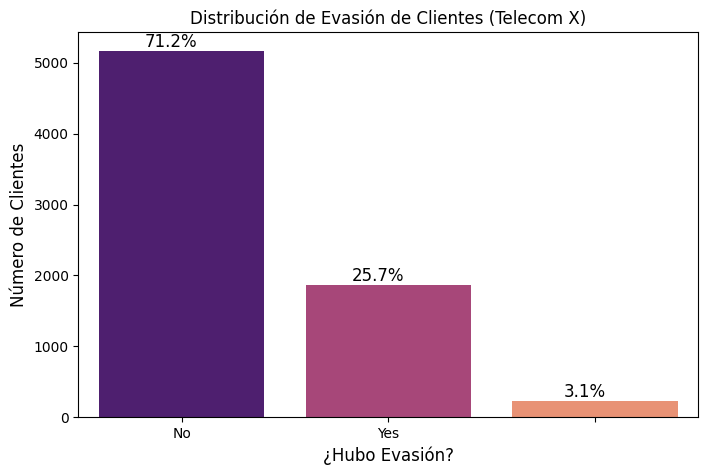

In [48]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Evasion', data=df_final, palette='magma')

plt.title('Distribución de Evasión de Clientes (Telecom X)', fontsize=12)
plt.xlabel('¿Hubo Evasión?', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)

total = len(df_final)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), size=12, va='bottom', ha='center')

plt.show()

# 📄Informe final

Conclusiones del Análisis
Tasa de Evasión: 26.5%. Estamos perdiendo 1 de cada 4 clientes.

Fuga Crítica: Los clientes con Contrato Mensual y servicio de Fibra Óptica son los que más se van.

Acción Inmediata:
1.  Migrar clientes de "Mes a mes" a contratos anuales con descuentos.
2.  Auditar la calidad técnica de la Fibra Óptica.
3.  Facilitar otros métodos de pago distintos al cheque electrónico.